# Exchange rate monthluy average

Her we use the monthly average data of exchange rate for 44 different currencies in comparison to USD. Here, we use the Volume Notation (1 domestic currency = X USD)

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv

load_dotenv()

True

In [23]:
DATA_DIR = os.getenv("DATA_FOLDER")
RESULTS_DIR = "data"

In [24]:
df = pd.read_excel(os.path.join(DATA_DIR, "exchange_rates", "exchange_rates.xlsx"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MMM YYYY             44 non-null     str    
 1   2025-01-01 00:00:00  44 non-null     float64
 2   2025-02-01 00:00:00  44 non-null     float64
 3   2025-03-01 00:00:00  44 non-null     float64
 4   2025-04-01 00:00:00  44 non-null     float64
 5   2025-05-01 00:00:00  44 non-null     float64
 6   2025-06-01 00:00:00  44 non-null     float64
 7   2025-07-01 00:00:00  44 non-null     float64
 8   2025-08-01 00:00:00  44 non-null     float64
 9   2025-09-01 00:00:00  44 non-null     float64
 10  2025-10-01 00:00:00  44 non-null     float64
 11  2025-11-01 00:00:00  44 non-null     float64
 12  2025-12-01 00:00:00  41 non-null     float64
dtypes: float64(12), str(1)
memory usage: 4.6 KB


In [25]:
df_curr = pd.read_excel(os.path.join(DATA_DIR, "exchange_rates", "currency_codes.xlsx"))
df_curr.info()

<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ENTITY           280 non-null    str    
 1   Currency         280 non-null    str    
 2   Alphabetic Code  277 non-null    str    
 3   Numeric Code     277 non-null    float64
 4   Minor unit       277 non-null    object 
dtypes: float64(1), object(1), str(3)
memory usage: 11.1+ KB


In [26]:
df["curr_code"] = df["MMM YYYY"].apply(lambda x: x.split("/")[0])
curr_codes = df["curr_code"].unique().tolist()
len(curr_codes)

44

In [27]:
df_curr.head()

,ENTITY,Currency,Alphabetic Code,Numeric Code,Minor unit
0,AFGHANISTAN,Afghani,AFN,971.0,2
1,ÅLAND ISLANDS,Euro,EUR,978.0,2
2,ALBANIA,Lek,ALL,8.0,2
3,ALGERIA,Algerian Dinar,DZD,12.0,2
4,AMERICAN SAMOA,US Dollar,USD,840.0,2


In [28]:
a, b = set(curr_codes), set(df_curr["Alphabetic Code"].unique().tolist())
a - b

{'BGN', 'HRK'}

In [29]:
df["curr_name"] = df["curr_code"].apply(lambda x: df_curr[df_curr["Alphabetic Code"] == x]["Currency"].values[0] if x in df_curr["Alphabetic Code"].values else np.nan)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MMM YYYY             44 non-null     str    
 1   2025-01-01 00:00:00  44 non-null     float64
 2   2025-02-01 00:00:00  44 non-null     float64
 3   2025-03-01 00:00:00  44 non-null     float64
 4   2025-04-01 00:00:00  44 non-null     float64
 5   2025-05-01 00:00:00  44 non-null     float64
 6   2025-06-01 00:00:00  44 non-null     float64
 7   2025-07-01 00:00:00  44 non-null     float64
 8   2025-08-01 00:00:00  44 non-null     float64
 9   2025-09-01 00:00:00  44 non-null     float64
 10  2025-10-01 00:00:00  44 non-null     float64
 11  2025-11-01 00:00:00  44 non-null     float64
 12  2025-12-01 00:00:00  41 non-null     float64
 13  curr_code            44 non-null     str    
 14  curr_name            42 non-null     str    
dtypes: float64(12), str(3)
memory usage: 5.3 KB


In [30]:
mask = df["curr_code"]=="BGN"
df.loc[mask, "curr_name"] = "Bulgarian Lev"

mask = df["curr_code"]=="HRK"
df.loc[mask, "curr_name"] = "Croatian Kuna"
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MMM YYYY             44 non-null     str    
 1   2025-01-01 00:00:00  44 non-null     float64
 2   2025-02-01 00:00:00  44 non-null     float64
 3   2025-03-01 00:00:00  44 non-null     float64
 4   2025-04-01 00:00:00  44 non-null     float64
 5   2025-05-01 00:00:00  44 non-null     float64
 6   2025-06-01 00:00:00  44 non-null     float64
 7   2025-07-01 00:00:00  44 non-null     float64
 8   2025-08-01 00:00:00  44 non-null     float64
 9   2025-09-01 00:00:00  44 non-null     float64
 10  2025-10-01 00:00:00  44 non-null     float64
 11  2025-11-01 00:00:00  44 non-null     float64
 12  2025-12-01 00:00:00  41 non-null     float64
 13  curr_code            44 non-null     str    
 14  curr_name            44 non-null     str    
dtypes: float64(12), str(3)
memory usage: 5.3 KB


In [31]:
months_map = {k: "Month_" + str(k.month) for k in df.columns if str(k).startswith("2025-")}
df.rename(columns=months_map, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MMM YYYY   44 non-null     str    
 1   Month_1    44 non-null     float64
 2   Month_2    44 non-null     float64
 3   Month_3    44 non-null     float64
 4   Month_4    44 non-null     float64
 5   Month_5    44 non-null     float64
 6   Month_6    44 non-null     float64
 7   Month_7    44 non-null     float64
 8   Month_8    44 non-null     float64
 9   Month_9    44 non-null     float64
 10  Month_10   44 non-null     float64
 11  Month_11   44 non-null     float64
 12  Month_12   41 non-null     float64
 13  curr_code  44 non-null     str    
 14  curr_name  44 non-null     str    
dtypes: float64(12), str(3)
memory usage: 5.3 KB


In [32]:
cols = ["curr_code", "curr_name"] + [col for col in df.columns if col.startswith("Month_")]
df1 = df.dropna()[cols].reset_index(drop=True)
df1.head()

,curr_code,curr_name,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,ARS,Argentine Peso,1042.00000,1057.80000,1067.90000,1124.10000,1151.5000,1179.40000,1271.20000,1325.10000,1405.10000,1438.40000,1428.90000,1447.70000
1,AUD,Australian Dollar,1.60510,1.58770,1.58740,1.59010,1.5539,1.53750,1.53060,1.53980,1.51640,1.52810,1.53790,1.50610
2,BRL,Brazilian Real,6.01640,5.76690,5.76100,5.78320,5.6684,5.54410,5.53280,5.44370,5.36650,5.38260,5.34290,5.45070
3,GBP,Pound Sterling,0.80993,0.79762,0.77434,0.76114,0.7480,0.73732,0.74175,0.74298,0.74042,0.74896,0.76096,0.74733
4,BGN,Bulgarian Lev,1.88840,1.87780,1.80990,1.74370,1.7331,1.69770,1.67590,1.68050,1.66730,1.68060,1.69180,1.66960


In [33]:
from src.utils import get_tsq

NORM_MODES = ["mean", "median", "interval", "base"]
Q_VALUES = (2, 3)


def get_accuracy(preds, actuals):
    ss_res = np.sum((preds - actuals) ** 2)
    ss_tot = np.sum((actuals - np.mean(actuals)) ** 2)
    return 1 - (ss_res / ss_tot), ss_res

def get_mape(preds, actuals):
    return np.mean(np.abs((actuals - preds) / (actuals + 1e-4))) * 100

def get_cagr(row, start_month, end_month):
    return ((row[f"Month_{end_month}"] / row[f"Month_{start_month}"]) ** (1 / (end_month - start_month)) - 1) * 100


def get_lagr(row, start_month, end_month):
    return ((row[f"Month_{end_month}"] - row[f"Month_{start_month}"]) / (1e-4 + row[f"Month_{start_month}"])) * 100


def add_growth_predictions(df, start_month, end_month, norm_modes=NORM_MODES, q_values=Q_VALUES):
    base_col = f"Month_{end_month}"

    # CAGR
    cagr_col = f"Month_{end_month}_CAGR_{start_month}_{end_month}"
    cagr_pred_col = f"Month_{end_month + 1}_pred_CAGR"
    df[cagr_col] = df.apply(lambda row: get_cagr(row, start_month, end_month), axis=1)
    df[cagr_pred_col] = df.apply(
        lambda row: (1 + (row[cagr_col] / 100)) * row[base_col],
        axis=1
    )

    # LAGR
    lagr_col = f"Month_{end_month}_LAGR_{start_month}_{end_month}"
    lagr_pred_col = f"Month_{end_month + 1}_pred_LAGR"
    df[lagr_col] = df.apply(lambda row: get_lagr(row, start_month, end_month), axis=1)
    df[lagr_pred_col] = df.apply(
        lambda row: (1 + (row[lagr_col] / 100)) * row[base_col],
        axis=1
    )

    # TSQ
    months = list(range(start_month, end_month + 1))
    for q in q_values:
        for norm_mode in norm_modes:
            tsq_col = f"Month_{end_month}_tsq{q}_{norm_mode}"
            pred_col = f"Month_{end_month + 1}_pred_TSQ{q}_{norm_mode}"
            df[tsq_col] = df.apply(
                lambda row: get_tsq(
                    months,
                    [row[f"Month_{yr}"] for yr in months],
                    q=q,
                    norm_mode=norm_mode
                ),
                axis=1
            )
            df[pred_col] = df.apply(
                lambda row: (1 + (row[tsq_col] / 100)) * row[base_col],
                axis=1
            )

    return df


def run_growth_pipeline(dfs_source, start_month, end_month, norm_modes=NORM_MODES, q_values=Q_VALUES):
    modeled_df = add_growth_predictions(df1, start_month, end_month, norm_modes, q_values)

    accuracy_data = []
    for method in ["CAGR", "LAGR"] + [f"TSQ2_{norm_mode}" for norm_mode in norm_modes] + [f"TSQ3_{norm_mode}" for norm_mode in norm_modes]:
        pred_col = f"Month_{end_month + 1}_pred_{method}"
        acc, mse = get_accuracy(modeled_df[pred_col], modeled_df[f"Month_{end_month + 1}"])
        accuracy_data.append({
            "Method": method,
            "Accuracy": acc,
            "RMSE": np.sqrt(mse),
            "MAPE": get_mape(modeled_df[pred_col], modeled_df[f"Month_{end_month + 1}"])
        })

    accuracy_df = pd.DataFrame(accuracy_data)
    return modeled_df, accuracy_df

## Compare predictive power of the different growth rates

In [34]:
acc_df = None
for month in range(3,12):
    _, acc = run_growth_pipeline(df1, start_month=1, end_month=month)
    acc["End_Month"] = month
    if acc_df is None:
        acc_df = acc
    else:
        acc_df = pd.concat([acc_df, acc])

/tmp/ipykernel_13038/3637990689.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[tsq_col] = df.apply(
/tmp/ipykernel_13038/3637990689.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[pred_col] = df.apply(
/tmp/ipykernel_13038/3637990689.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

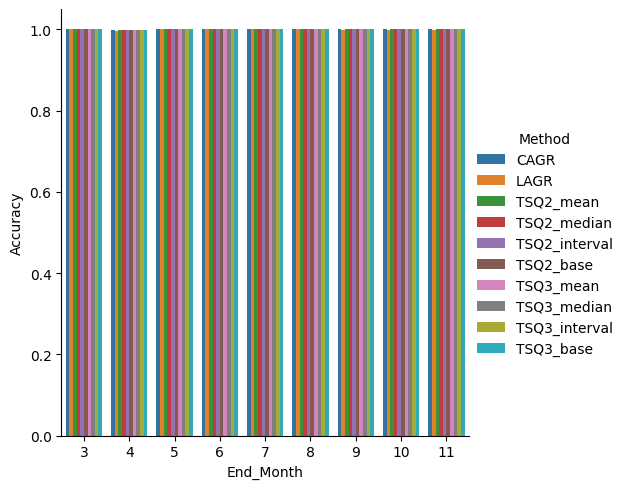

In [35]:
sns.catplot(data=acc_df, x="End_Month", y="Accuracy", hue="Method", kind="bar")

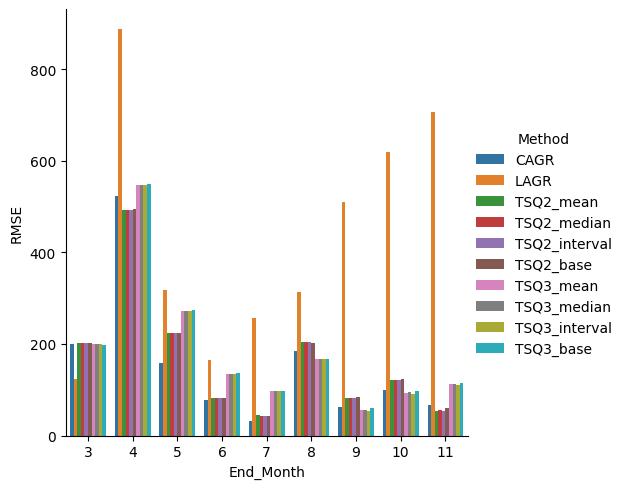

In [36]:
sns.catplot(data=acc_df, x="End_Month", y="RMSE", hue="Method", kind="bar")

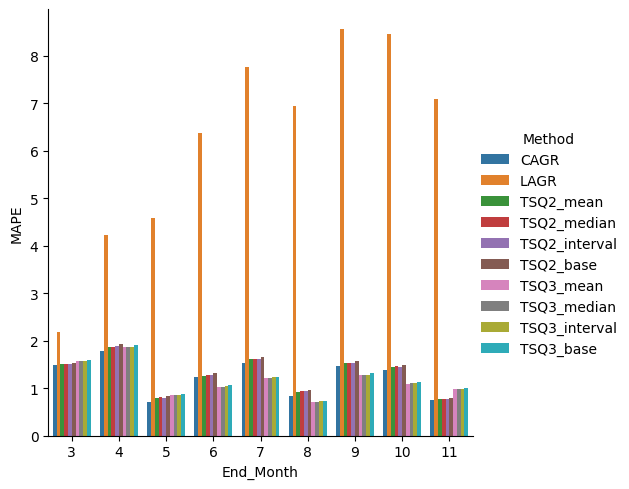

In [37]:
sns.catplot(data=acc_df, x="End_Month", y="MAPE", hue="Method", kind="bar")